# Convolution from first principles

**Learning objective:** Compute one local filter response manually and match it with TensorFlow's `tf.nn.conv2d`.

This notebook is part of the TensorFlow/Keras learning track. It is designed to be read top-to-bottom: intuition → shapes → mathematics → TensorFlow implementation → observed result → interpretation.

> GitHub renders the committed executed output as a static learning artifact. Clone the repository and rerun it in Jupyter/VS Code for live experimentation.


In [1]:
import os, warnings, random
from pathlib import Path
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

print("TensorFlow:", tf.__version__)
print("Keras:", tf.keras.__version__ if hasattr(tf.keras, "__version__") else "bundled with TensorFlow")
print("Execution device(s):", [d.device_type for d in tf.config.list_logical_devices()])


2026-09-21 07:15:28.795878: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1789974928.811351    3755 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1789974928.815669    3755 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


TensorFlow: 2.18.1
Keras: 3.15.1
Execution device(s): ['CPU']


2026-09-21 07:15:30.518836: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [2]:
image=np.array([[0,0,0,0,0],[0,1,1,0,0],[0,1,1,0,0],[0,0,0,1,1],[0,0,0,1,1]],dtype="float32")
kernel=np.array([[1,0,-1],[1,0,-1],[1,0,-1]],dtype="float32")
patch=image[:3,:3]; manual=float(np.sum(patch*kernel))
print("patch:\n",patch); print("kernel:\n",kernel); print("manual dot-product response:",manual)


patch:
 [[0. 0. 0.]
 [0. 1. 1.]
 [0. 1. 1.]]
kernel:
 [[ 1.  0. -1.]
 [ 1.  0. -1.]
 [ 1.  0. -1.]]
manual dot-product response: -2.0


TensorFlow first response: -2.0
full feature map:
 [[-2.  2.  2.]
 [-2.  1.  1.]
 [-1. -1. -1.]]


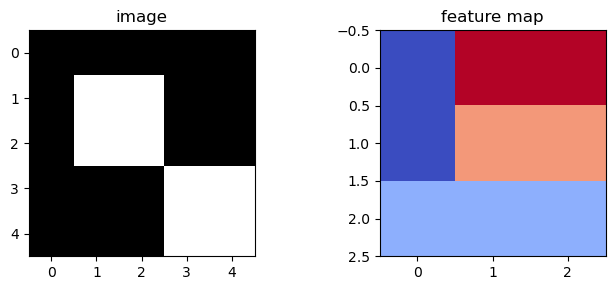

In [3]:
tf_out=tf.nn.conv2d(image[None,:,:,None],kernel[:,:,None,None],strides=1,padding="VALID")
print("TensorFlow first response:",float(tf_out.numpy()[0,0,0,0])); print("full feature map:\n",tf_out.numpy()[0,:,:,0])
plt.figure(figsize=(7,3)); plt.subplot(1,2,1); plt.imshow(image,cmap="gray"); plt.title("image"); plt.subplot(1,2,2); plt.imshow(tf_out.numpy()[0,:,:,0],cmap="coolwarm"); plt.title("feature map"); plt.tight_layout(); plt.show()


Deep-learning libraries typically implement cross-correlation (no kernel flip) while using the conventional term convolution. The learning behavior is unaffected because filter values are learned.
